In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay

In [91]:
def line_interpolation(x, y, u, v, X, Y) -> np.ndarray:
    """
    Interpolates the wind speed data onto a regular grid.

    Parameters:
    - x: n_particles x n_values array of x-coordinates
    - y: n_particles x n_values array of y-coordinates
    - u: n_particles x n_values array of u-component of wind speed
    - v: n_particles x n_values array of v-component of wind speed
    - X: 2D np.ndarray of x-coordinates for interpolation grid
    - Y: 2D np.ndarray of y-coordinates for interpolation grid

    Returns:
    - U: 2D np.ndarray of interpolated u-component of wind speed
    - V: 2D np.ndarray of interpolated v-component of wind speed
    """

    U = np.full(X.shape, np.nan)
    V = np.full(X.shape, np.nan)

    # Create a mask to find out if the X,Y grid point is part of the convex hull of the data points
    points  = np.column_stack((x.flatten(), y.flatten()))
    tri     = Delaunay(points)
    mask    = tri.find_simplex(np.column_stack((X.flatten(), Y.flatten()))) >= 0
    mask    = mask.reshape(X.shape)

    # Build segments from the data points based on starting point and vector to the next point
    segments = np.array([])
    for i in range(x.shape[0] - 1):
        for j in range(x.shape[1]):
            if segments.size == 0:
                segments = np.array([x[i, j], y[i, j], x[i + 1, j] - x[i, j], y[i + 1, j] - y[i, j], u[i, j], v[i, j], u[i + 1, j], v[i + 1, j]])
            else:
                segments = np.vstack([segments, [x[i, j], y[i, j], x[i + 1, j] - x[i, j], y[i + 1, j] - y[i, j], u[i, j], v[i, j], u[i + 1, j], v[i + 1, j]]])

    fig, ax = plt.subplots()
    for seg in segments:
        ax.plot([seg[0], seg[0] + seg[2]], [seg[1], seg[1] + seg[3]], 'k-', linewidth=0.5)
    ax.plot(segments[:, 0], segments[:, 1], 'o', markersize=1, color="#FF0000")
    ax.plot(X[mask], Y[mask], 'o', markersize=1, color="#0000FF")
    plt.title('Segments and Grid Points')
    plt.xlabel('x (m)')
    plt.ylabel('y (m)')

    for j in range(X.shape[0]):
        for k in range(X.shape[1]):
            if mask[j, k]:
                # Calculate the downstream, cross-stream distance from the grid point to each segment
                downstream_distance         = np.zeros(segments.shape[0])
                cross_stream_distance       = np.zeros(segments.shape[0])
                percentage_along_segment    = np.zeros(segments.shape[0])
                angle_to_segment            = np.zeros(segments.shape[0])

                for i in range(segments.shape[0]):
                    # Vector from segment start to grid point
                    dx = X[j, k] - segments[i, 0]
                    dy = Y[j, k] - segments[i, 1]

                    # Segment vector
                    seg_dx = segments[i, 2]
                    seg_dy = segments[i, 3]

                    # Calculate the projection of the point onto the segment by dot product
                    seg_length_squared = seg_dx**2 + seg_dy**2
                    t = (dx * seg_dx + dy * seg_dy) / seg_length_squared

                    # Calculate angle between segment and point vector
                    angle = np.arctan2(dy, dx) - np.arctan2(seg_dy, seg_dx)
                    angle = (angle + np.pi) % (2 *np.pi) - np.pi  # Normalize angle to [-pi, pi]
                    angle_to_segment[i] = angle
                    # 

                    if t < 0:
                        # the grid point is before the segment start -> ignore
                        downstream_distance[i] = np.nan
                        cross_stream_distance[i] = np.nan
                        continue
                    elif t > 1:
                        # the grid point is after the segment end -> ignore
                        downstream_distance[i] = np.nan
                        cross_stream_distance[i] = np.nan
                        continue

                    percentage_along_segment[i] = t

                    # Closest point on the segment
                    closest_x = segments[i, 0] + t * seg_dx
                    closest_y = segments[i, 1] + t * seg_dy
                    
                    # This needs to be the distance from the grid point to the closest point on the segment, projected onto the segment direction for downstream and perpendicular for cross-stream
                    dx = X[j, k] - closest_x
                    dy = Y[j, k] - closest_y
                    
                    downstream_distance[i]      = np.cos(angle) * np.sqrt(dx**2 + dy**2)
                    cross_stream_distance[i]    = np.sin(angle) * np.sqrt(dx**2 + dy**2)

                # Find the index of the two closest cross-stream segments
                closest_segment_idxs = np.argsort(np.abs(cross_stream_distance))[0:2]

                # If the difference between the angles to the two closest segments is smaller than 90 deg, do not fill in the grid point
                # if np.abs(angle_to_segment[closest_segment_idxs[0]] - angle_to_segment[closest_segment_idxs[1]]) < np.pi / 2:
                #     continue

                ax.plot([X[j, k], segments[closest_segment_idxs[0], 0] + percentage_along_segment[closest_segment_idxs[0]] * segments[closest_segment_idxs[0], 2]],
                        [Y[j, k], segments[closest_segment_idxs[0], 1] + percentage_along_segment[closest_segment_idxs[0]] * segments[closest_segment_idxs[0], 3]], 'r-', linewidth=1)
                ax.plot([X[j, k], segments[closest_segment_idxs[1], 0] + percentage_along_segment[closest_segment_idxs[1]] * segments[closest_segment_idxs[1], 2]],
                        [Y[j, k], segments[closest_segment_idxs[1], 1] + percentage_along_segment[closest_segment_idxs[1]] * segments[closest_segment_idxs[1], 3]], 'r:', linewidth=0.5)

                frac_closest_seg = np.abs(cross_stream_distance[closest_segment_idxs[0]]) / (np.abs(cross_stream_distance[closest_segment_idxs[0]]) + np.abs(cross_stream_distance[closest_segment_idxs[1]]))

                # same blending as for V: linear along each segment, then cross-stream blend
                denom = np.abs(cross_stream_distance[closest_segment_idxs[0]]) + np.abs(cross_stream_distance[closest_segment_idxs[1]])
                if denom == 0:
                    frac_closest_seg = 0.5  # exactly centered between both segments
                else:
                    frac_closest_seg = np.abs(cross_stream_distance[closest_segment_idxs[0]]) / denom

                U[j, k] = (1 - frac_closest_seg) * (
                    segments[closest_segment_idxs[0], 4]
                    + percentage_along_segment[closest_segment_idxs[0]]
                    * (segments[closest_segment_idxs[0], 6] - segments[closest_segment_idxs[0], 4])
                ) + frac_closest_seg * (
                    segments[closest_segment_idxs[1], 4]
                    + percentage_along_segment[closest_segment_idxs[1]]
                    * (segments[closest_segment_idxs[1], 6] - segments[closest_segment_idxs[1], 4])
                )
                V[j,k] = (1 - frac_closest_seg) * (
                    segments[closest_segment_idxs[0], 5] 
                    + percentage_along_segment[closest_segment_idxs[0]] 
                    * (segments[closest_segment_idxs[0], 7] - segments[closest_segment_idxs[0], 5])
                ) + (frac_closest_seg) * (
                    segments[closest_segment_idxs[1], 5] 
                    + percentage_along_segment[closest_segment_idxs[1]] 
                    * (segments[closest_segment_idxs[1], 7] - segments[closest_segment_idxs[1], 5]))

    plt.title('Segments and Grid Points with Closest Segments')
    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    ax.set_aspect('equal', adjustable='box')
    plt.show()

    return U, V

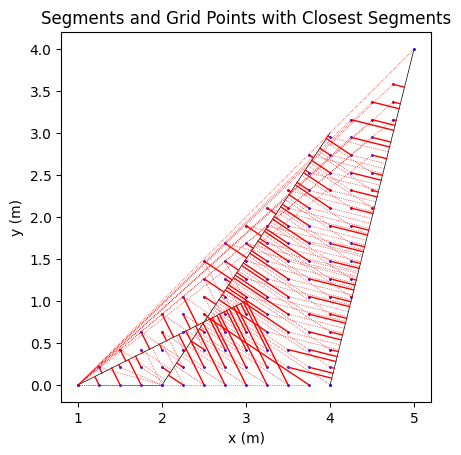

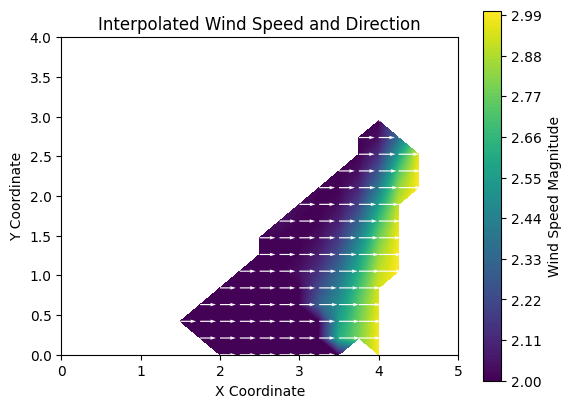

In [ ]:
x = np.array([[1.0, 2.0, 4.0], [3.0, 4.0, 5.0]])
y = np.array([[0.0, 0.0, 0.0], [4.0, 4.0, 4.0]])

u = np.array([[2.0, 2.0, 3.0], [2.0, 2.0, 3.0]])
v = np.array([[0.0, 0.0, 0.0], [0.0, 0.0, 0.0]])

X, Y = np.meshgrid(np.linspace(0, 5, 21), np.linspace(0, 4, 20))

U, V = line_interpolation(x, y, u, v, X, Y)

fig, ax = plt.subplots()
contour = ax.contourf(X, Y, np.sqrt(U**2 + V**2), levels=100, cmap='viridis')
cbar = plt.colorbar(contour, ax=ax, label='Wind Speed Magnitude')
cbar.set_label('Wind Speed Magnitude')
ax.quiver(X, Y, U, V, color='white', scale=50)
ax.set_title('Interpolated Wind Speed and Direction')
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_aspect('equal', adjustable='box')
plt.show()